# 02 Holdout Visual Compare - finetune_v1

`01_training_result_review_finetune_v1.ipynb`에서는 Colab 학습 로그를 보고, `finetune_v1`이 수치상으로 학습되었는지를 확인했음.

이번 노트북에서는 한 단계 더 나아가서, **학습에 직접 넣지 않은 holdout 주행 프레임**에서 아래 두 모델의 lane output을 눈으로 비교함.

- `pretrained`: 공식 `ResNet18_CULane.pth`
- `finetuned`: `finetune_v1` full run의 `best.pth`

이 노트북의 목적은 명확함.

1. pseudo-label validation metric이 실제 이미지에서도 의미 있는 개선으로 보이는지 확인함.
2. pretrained 모델이 우리 map 도메인에서 어떻게 실패하는지 다시 확인함.
3. fine-tuned 모델이 노란 양쪽 차선을 더 안정적으로 잡는지 확인함.
4. 다음 단계인 ONNX export / Pi latency / 실제 주행 테스트로 넘어가도 되는지 판단함.

주의할 점:

- 여기서 그리는 `GT`는 사람이 직접 라벨링한 정답이 아니라, 우리가 구축한 HSV + component-poly 기반 pseudo label임.
- 따라서 `GT와 비슷하다 = 무조건 정답`은 아님.
- 그래도 holdout은 학습 데이터에서 제외한 맵 주행 프레임이므로, **도메인 적응이 실제 주행 이미지에 일반화되는지 보는 데 의미가 있음.**

## 1. 경로와 실행 설정

이 노트북은 로컬 VS Code에서 실행하는 것을 기본으로 함.

필요한 입력은 이미 로컬에 있음.

```text
06_lane_model_finetuning/
├─ colab_outputs/finetune_v1/MapLane_Field1Field2_full/.../ckpt/best.pth
└─ notebooks/02_holdout_visual_compare_finetune_v1.ipynb

30_pipelines/culane_pseudo_dataset_builder/datasets/
└─ map_culane_holdout_eval_component_poly/

20_shared_assets/models/model/
└─ ResNet18_CULane.pth
```

기본 설정은 holdout 각 scene에서 일부 샘플만 뽑아 비교함. 전체 holdout을 다 돌리고 싶으면 `SAMPLES_PER_SCENE` 값을 늘리면 됨.

In [1]:
from pathlib import Path
import sys
import os
import json
import random
import pickle
import gc
from datetime import datetime

try:
    import cv2
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
except Exception as e:
    raise RuntimeError('이 노트북은 cv2, numpy, pandas, matplotlib이 필요함. kernel 환경을 확인해야 함.') from e

PROJECT_ROOT = Path(r'~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization')
EXP_ROOT = PROJECT_ROOT / '10_experiments' / '06_lane_model_finetuning'
OUTPUT_ROOT = EXP_ROOT / 'colab_outputs' / 'finetune_v1'
FULL_ROOT = OUTPUT_ROOT / 'MapLane_Field1Field2_full'
HOLDOUT_ROOT = PROJECT_ROOT / '30_pipelines' / 'culane_pseudo_dataset_builder' / 'datasets' / 'map_culane_holdout_eval_component_poly'
PRETRAINED_PTH = PROJECT_ROOT / '20_shared_assets' / 'models' / 'model' / 'ResNet18_CULane.pth'

SAMPLES_PER_SCENE = 8
CONF_THRESHOLD = 0.35
NMS_TOPK = 4
RANDOM_SEED = 0

REVIEW_ROOT = EXP_ROOT / 'review_outputs' / '02_holdout_visual_compare_finetune_v1'
OVERLAY_DIR = REVIEW_ROOT / 'overlays'
CACHE_PATH = REVIEW_ROOT / 'prediction_cache.pkl'
SUMMARY_CSV = REVIEW_ROOT / 'prediction_summary.csv'

REVIEW_ROOT.mkdir(parents=True, exist_ok=True)
OVERLAY_DIR.mkdir(parents=True, exist_ok=True)

# Windows의 Python/OpenCV는 긴 경로(대략 260자 이상)를 못 읽는 경우가 있음.
# holdout image 경로가 290자 안팎이라, 파일이 실제로 있어도 Path.exists()가 False가 될 수 있음.
def win_long_path(path):
    p = Path(path)
    s = str(p if p.is_absolute() else p.resolve())
    if os.name == 'nt' and not s.startswith("\\\\?\\"):
        return "\\\\?\\" + s
    return s

def path_exists(path):
    return Path(win_long_path(path)).exists()

def read_text_any(path, encoding='utf-8'):
    with open(win_long_path(path), 'r', encoding=encoding) as f:
        return f.read()

def cv2_imread_color(path):
    # cv2.imread(str(path))도 긴 경로에서 실패할 수 있어서 bytes -> imdecode로 우회함.
    data = np.fromfile(win_long_path(path), dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, cv2.IMREAD_COLOR)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('EXP_ROOT:', EXP_ROOT)
print('HOLDOUT_ROOT exists:', path_exists(HOLDOUT_ROOT), HOLDOUT_ROOT)
print('PRETRAINED_PTH exists:', path_exists(PRETRAINED_PTH), PRETRAINED_PTH)
print('REVIEW_ROOT:', REVIEW_ROOT)

assert path_exists(PROJECT_ROOT), PROJECT_ROOT
assert path_exists(EXP_ROOT), EXP_ROOT
assert path_exists(HOLDOUT_ROOT), HOLDOUT_ROOT
assert path_exists(PRETRAINED_PTH), PRETRAINED_PTH

PROJECT_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization
EXP_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning
HOLDOUT_ROOT exists: True ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\30_pipelines\culane_pseudo_dataset_builder\datasets\map_culane_holdout_eval_component_poly
PRETRAINED_PTH exists: True ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\models\model\ResNet18_CULane.pth
REVIEW_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\02_holdout_visual_compare_finetune_v1


## 2. full run과 checkpoint 확인

`finetune_v1` full run은 Colab에서 받은 결과 폴더 안에 있음. 여기서는 full run 폴더를 자동으로 찾고, 그 안의 `config.py`, `code/`, `ckpt/best.pth`를 사용함.

중요한 점:

- `code/`는 Colab 학습 당시 저장된 코드 스냅샷임.
- 그래서 현재 다른 reference repo가 바뀌어도, 학습에 쓴 코드 기준으로 비교할 수 있음.
- `best.pth`는 validation metric 기준 가장 좋았던 checkpoint임.

In [2]:
def find_single_run_dir(root: Path) -> Path:
    runs = sorted([p for p in root.iterdir() if p.is_dir()])
    if len(runs) != 1:
        print('run dirs:')
        for p in runs:
            print(' -', p)
        raise RuntimeError(f'expected exactly one run dir under {root}, got {len(runs)}')
    return runs[0]

FULL_RUN = find_single_run_dir(FULL_ROOT)
CODE_DIR = FULL_RUN / 'code'
CONFIG_PATH = FULL_RUN / 'config.py'
FINETUNED_PTH = FULL_RUN / 'ckpt' / 'best.pth'

for name, path in [
    ('FULL_RUN', FULL_RUN),
    ('CODE_DIR', CODE_DIR),
    ('CONFIG_PATH', CONFIG_PATH),
    ('FINETUNED_PTH', FINETUNED_PTH),
]:
    print(f'{name}: {path} exists={path_exists(path)}')
    assert path_exists(path), path

print('finetuned size MB:', round(FINETUNED_PTH.stat().st_size / 1024 / 1024, 2))
print('pretrained size MB:', round(PRETRAINED_PTH.stat().st_size / 1024 / 1024, 2))

FULL_RUN: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8 exists=True
CODE_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8\code exists=True
CONFIG_PATH: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8\config.py exists=True
FINETUNED_PTH: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8\ckpt\best.pth exists=True
finetuned size MB: 131.63
pretrained size MB: 43.98


## 3. holdout 샘플 선정

holdout 데이터는 학습에서 제외해둔 맵 주행 프레임임.

현재 holdout은 크게 두 줄기로 구성됨.

- `field1_sign_background`: 1차 실험에서 표지판 background로 수집했지만 실제로는 맵을 순회하며 찍힌 주행 이미지
- `field2_traffic_background`: 2차 실험에서 신호등 background로 수집했지만 실제로는 맵 주행 이미지

주의할 점:

- CULane dataset의 `list/test.txt`만 읽으면 holdout의 일부 split만 보게 됨.
- 현재 holdout `test.txt`는 우연히 `field2_traffic_background`만 포함하고 있어서, field1 배경 주행 프레임이 빠짐.
- 그래서 이 노트북에서는 `build_manifest.csv`에서 `status == usable`인 전체 holdout 후보를 읽고, scene별로 균등 샘플링함.

이 방식이 지금 목적에 더 맞음. 우리는 official validation 재계산이 아니라, **학습에 넣지 않은 주행 프레임들에서 모델 출력이 어떻게 보이는지 시각 확인**하려는 것이기 때문임.

In [3]:
TEST_LIST = HOLDOUT_ROOT / 'list' / 'test.txt'
MANIFEST = HOLDOUT_ROOT / 'build_manifest.csv'

assert path_exists(TEST_LIST), TEST_LIST
assert path_exists(MANIFEST), MANIFEST

manifest_df = pd.read_csv(win_long_path(MANIFEST))
print('manifest rows:', len(manifest_df))
print('status counts:')
print(manifest_df['status'].value_counts(dropna=False))
print('\nscene counts:')
print(manifest_df['scene'].value_counts(dropna=False))

usable_df = manifest_df[manifest_df['status'] == 'usable'].copy()
usable_df['rel'] = usable_df['dataset_image'].astype(str)
usable_df['img_path'] = usable_df['rel'].map(lambda rel: HOLDOUT_ROOT / rel)
usable_df['exists'] = usable_df['img_path'].map(path_exists)

print('\nusable rows:', len(usable_df))
print('usable scene counts:')
print(usable_df['scene'].value_counts())
print('missing usable images:', int((~usable_df['exists']).sum()))
assert usable_df['exists'].all(), 'some usable manifest images do not exist'

def evenly_sample(group: pd.DataFrame, n: int) -> pd.DataFrame:
    group = group.sort_values('rel').reset_index(drop=True)
    if len(group) <= n:
        return group
    idx = np.linspace(0, len(group) - 1, n).round().astype(int)
    return group.iloc[idx].reset_index(drop=True)

sample_df = (
    usable_df.groupby('scene', group_keys=False)
    .apply(lambda g: evenly_sample(g, SAMPLES_PER_SCENE))
    .reset_index(drop=True)
)

sample_df = sample_df[['scene', 'rel', 'img_path', 'exists']]
print('\nsample rows:', len(sample_df))
print(sample_df[['scene', 'rel', 'exists']].head(30))

if not sample_df['exists'].all():
    missing = sample_df[~sample_df['exists']][['scene', 'rel', 'img_path']]
    display(missing)
    raise AssertionError('some sampled images do not exist. Windows long-path helper may need checking.')

manifest rows: 734
status counts:
status
usable    722
reject     12
Name: count, dtype: int64

scene counts:
scene
field1_sign_background       415
field2_traffic_background    319
Name: count, dtype: int64

usable rows: 722
usable scene counts:
scene
field1_sign_background       413
field2_traffic_background    309
Name: count, dtype: int64
missing usable images: 0

sample rows: 16
                        scene  \
0      field1_sign_background   
1      field1_sign_background   
2      field1_sign_background   
3      field1_sign_background   
4      field1_sign_background   
5      field1_sign_background   
6      field1_sign_background   
7      field1_sign_background   
8   field2_traffic_background   
9   field2_traffic_background   
10  field2_traffic_background   
11  field2_traffic_background   
12  field2_traffic_background   
13  field2_traffic_background   
14  field2_traffic_background   
15  field2_traffic_background   

                                                  r

~\AppData\Local\Temp\ipykernel_55304\2442750940.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: evenly_sample(g, SAMPLES_PER_SCENE))


## 4. 공식 코드 기준 inference 함수 준비

여기서 중요한 부분은 “우리가 임의의 새 모델을 만든다”가 아니라, **CLRKDNet 공식 코드의 모델 구조와 `get_lanes()` 후처리 경로를 그대로 사용한다**는 점임.

다만 로컬 실행을 위해 다음만 처리함.

- Colab 학습 당시 저장된 `code/` 폴더를 import 경로에 추가함.
- GPU가 있으면 GPU, 없으면 CPU로 inference함.
- checkpoint는 `module.` prefix 유무와 상관없이 로드되도록 처리함.
- confidence threshold는 상단의 `CONF_THRESHOLD`에서 조절함.

이 셀이 실패하면 대부분 kernel에 `torch`가 없거나, PyTorch/torchvision 환경이 맞지 않는 문제임. 그 경우 `<env>` 또는 torch가 설치된 환경으로 kernel을 바꾸면 됨.

In [4]:
try:
    import torch
except Exception as e:
    raise RuntimeError('torch가 없는 kernel임. <env> 또는 torch 설치 환경으로 실행해야 함.') from e

# 이전 노트북에서 다른 CLRKDNet 코드가 import된 상태면 같은 이름의 모듈이 재사용될 수 있음.
# 02 노트북은 Colab full run에 저장된 code snapshot 기준으로 비교해야 하므로 관련 모듈을 비우고 다시 import함.
for module_name in list(sys.modules):
    if module_name == 'clrkd' or module_name.startswith('clrkd.') or module_name == 'mmcv' or module_name.startswith('mmcv.'):
        del sys.modules[module_name]

if str(CODE_DIR) in sys.path:
    sys.path.remove(str(CODE_DIR))
sys.path.insert(0, str(CODE_DIR))

from clrkd.utils.config import Config
import clrkd.models  # registry 등록용
from clrkd.models.registry import build_net


def load_config_windows_safe(config_path: Path):
    # 공식 Config.fromfile()은 Windows에서 NamedTemporaryFile을 연 채 copyfile을 시도해서
    # PermissionError가 날 수 있음. 생성된 map config에는 _base_가 없으므로 직접 exec해서 Config 객체를 만듦.
    text = read_text_any(config_path)
    namespace = {}
    exec(compile(text, str(config_path), 'exec'), namespace)
    cfg_dict = {k: v for k, v in namespace.items() if not k.startswith('__')}
    return Config(cfg_dict, cfg_text=text, filename=str(config_path))

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch:', torch.__version__)
print('DEVICE:', DEVICE)


def torch_load(path: Path):
    try:
        return torch.load(win_long_path(path), map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(win_long_path(path), map_location=DEVICE)


def clean_state_dict(raw_state):
    cleaned = {}
    for k, v in raw_state.items():
        if k.startswith('module.'):
            k = k[len('module.'):]
        cleaned[k] = v
    return cleaned


def load_clrkd_model(checkpoint_path: Path, conf_threshold: float = CONF_THRESHOLD):
    cfg = load_config_windows_safe(CONFIG_PATH)
    cfg.test_parameters.conf_threshold = conf_threshold
    cfg.test_parameters.nms_topk = NMS_TOPK

    model = build_net(cfg)
    ckpt = torch_load(checkpoint_path)
    raw_state = ckpt['net'] if isinstance(ckpt, dict) and 'net' in ckpt else ckpt
    state = clean_state_dict(raw_state)

    model_state = model.state_dict()
    compatible = {}
    skipped = []
    for k, v in state.items():
        if k in model_state and tuple(v.shape) == tuple(model_state[k].shape):
            compatible[k] = v
        else:
            skipped.append(k)

    missing, unexpected = model.load_state_dict(compatible, strict=False)
    model.to(DEVICE)
    model.eval()

    info = {
        'checkpoint': str(checkpoint_path),
        'loaded_tensors': len(compatible),
        'skipped_tensors': len(skipped),
        'missing_tensors': len(missing),
        'unexpected_tensors': len(unexpected),
    }
    return model, cfg, info


def preprocess_bgr_for_clrkd(img_bgr, cfg):
    crop = img_bgr[cfg.cut_height:, :, :]
    resized = cv2.resize(crop, (cfg.img_w, cfg.img_h), interpolation=cv2.INTER_CUBIC)
    tensor = resized.astype(np.float32) / 255.0
    tensor = torch.from_numpy(tensor).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    return tensor


def predict_lanes_for_image(model, cfg, image_path: Path):
    img_bgr = cv2_imread_color(image_path)
    if img_bgr is None:
        raise RuntimeError(f'failed to read image: {image_path}')
    tensor = preprocess_bgr_for_clrkd(img_bgr, cfg)
    with torch.no_grad():
        output = model({'img': tensor})
        lanes = model.heads.get_lanes(output)[0]
    serial = []
    for lane in lanes:
        pts = lane.to_array(cfg)
        if pts is None or len(pts) < 2:
            continue
        score = lane.metadata.get('conf', None)
        try:
            score = float(score.detach().cpu()) if hasattr(score, 'detach') else float(score)
        except Exception:
            score = None
        serial.append({'points': pts.tolist(), 'score': score})
    return serial

print('inference helpers ready')

torch: 2.11.0+cpu
DEVICE: cpu
inference helpers ready


## 5. pseudo GT와 prediction 실행

여기서는 동일한 holdout 샘플에 대해 두 번 inference함.

1. pretrained 공식 CULane 모델
2. fine-tuned v1 모델

결과는 `review_outputs/02_holdout_visual_compare_finetune_v1/prediction_cache.pkl`에 저장함. 같은 샘플/설정으로 다시 실행하면 cache를 재사용할 수 있음.

모델 출력 해석:

- CLRKDNet은 조향각을 직접 내는 모델이 아님.
- 출력은 여러 lane 후보이고, `get_lanes()`가 confidence threshold + NMS를 거쳐 최종 lane 곡선을 만든 것임.
- 따라서 여기서 보는 것은 “차가 어떻게 조향할지”가 아니라, “제어 로직에 넘길 lane 곡선이 얼마나 말이 되는지”임.

In [5]:
def read_lines_txt(lines_path: Path):
    lanes = []
    if not path_exists(lines_path):
        return lanes
    for line in read_text_any(lines_path).splitlines():
        vals = [float(x) for x in line.strip().split()]
        if len(vals) < 4:
            continue
        pts = np.array(vals, dtype=np.float32).reshape(-1, 2)
        lanes.append({'points': pts.tolist(), 'score': None})
    return lanes


def run_or_load_predictions(force=False):
    settings = {
        'sample_rels': sample_df['rel'].tolist(),
        'conf_threshold': CONF_THRESHOLD,
        'nms_topk': NMS_TOPK,
        'pretrained': str(PRETRAINED_PTH),
        'finetuned': str(FINETUNED_PTH),
    }
    if path_exists(CACHE_PATH) and not force:
        with open(win_long_path(CACHE_PATH), 'rb') as f:
            cache = pickle.load(f)
        if cache.get('settings') == settings:
            print('loaded cache:', CACHE_PATH)
            return cache
        print('cache exists but settings changed. rerun inference.')

    cache = {'settings': settings, 'samples': []}

    for model_name, ckpt_path in [('pretrained', PRETRAINED_PTH), ('finetuned', FINETUNED_PTH)]:
        print(f'\nloading {model_name}: {ckpt_path}')
        model, cfg, info = load_clrkd_model(ckpt_path)
        print(info)

        for i, row in sample_df.iterrows():
            if model_name == 'pretrained':
                gt_lines = read_lines_txt(Path(row['img_path']).with_suffix('.lines.txt'))
                cache['samples'].append({
                    'rel': row['rel'],
                    'scene': row['scene'],
                    'img_path': str(row['img_path']),
                    'gt': gt_lines,
                    'predictions': {},
                })
            pred = predict_lanes_for_image(model, cfg, Path(row['img_path']))
            cache['samples'][i]['predictions'][model_name] = pred
            print(f'{model_name:10s} {i+1:02d}/{len(sample_df)} scene={row["scene"]} lanes={len(pred)}')

        del model
        gc.collect()
        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    with open(win_long_path(CACHE_PATH), 'wb') as f:
        pickle.dump(cache, f)
    print('\nsaved cache:', CACHE_PATH)
    return cache

cache = run_or_load_predictions(force=False)
len(cache['samples'])

cache exists but settings changed. rerun inference.

loading pretrained: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\models\model\ResNet18_CULane.pth
{'checkpoint': '~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\20_shared_assets\\models\\model\\ResNet18_CULane.pth', 'loaded_tensors': 173, 'skipped_tensors': 0, 'missing_tensors': 0, 'unexpected_tensors': 0}
pretrained 01/16 scene=field1_sign_background lanes=0
pretrained 02/16 scene=field1_sign_background lanes=0
pretrained 03/16 scene=field1_sign_background lanes=0
pretrained 04/16 scene=field1_sign_background lanes=0
pretrained 05/16 scene=field1_sign_background lanes=0
pretrained 06/16 scene=field1_sign_background lanes=0
pretrained 07/16 scene=field1_sign_background lanes=0
pretrained 08/16 scene=field1_sign_background lanes=0
pretrained 09/16 scene=field2_traffic_background lanes=0
pretrained 10/16 scene=field2_traffic_background lanes=0
pretrained 11/16 scene=field2_

16

## 6. 예측 개수 요약

먼저 이미지별 lane 개수만 요약함.

이 표는 시각 결과를 보기 전에 빠르게 이상 징후를 찾는 용도임.

- `gt_count`: pseudo label이 가진 lane 수
- `pretrained_count`: 공식 CULane pretrained 모델이 찾은 lane 수
- `finetuned_count`: v1 fine-tuned 모델이 찾은 lane 수

정상적인 목표는 “항상 2개를 맞춘다”가 아님. 코너, 교차로, 한쪽 차선만 잘 보이는 상황에서는 1개가 나올 수도 있음. 다만 holdout 대부분에서 fine-tuned가 pretrained보다 더 자주 lane을 잡아야 함.

In [6]:
summary_rows = []
for s in cache['samples']:
    summary_rows.append({
        'scene': s['scene'],
        'file': Path(s['rel']).name,
        'gt_count': len(s['gt']),
        'pretrained_count': len(s['predictions'].get('pretrained', [])),
        'finetuned_count': len(s['predictions'].get('finetuned', [])),
    })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(win_long_path(SUMMARY_CSV), index=False, encoding='utf-8-sig')
print('saved:', SUMMARY_CSV)
print('\nmean counts by scene:')
print(summary_df.groupby('scene')[['gt_count', 'pretrained_count', 'finetuned_count']].mean())
summary_df

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\02_holdout_visual_compare_finetune_v1\prediction_summary.csv

mean counts by scene:
                           gt_count  pretrained_count  finetuned_count
scene                                                                 
field1_sign_background        1.875               0.0              3.5
field2_traffic_background     1.750               0.0              3.5


,scene,file,gt_count,pretrained_count,finetuned_count
0,field1_sign_background,20260430_175024_signs_background_moving_mixed_...,2,0,4
1,field1_sign_background,20260430_175038_signs_background_moving_mixed_...,2,0,4
2,field1_sign_background,20260430_175051_signs_background_moving_mixed_...,2,0,4
3,field1_sign_background,20260430_175104_signs_background_moving_mixed_...,2,0,4
4,field1_sign_background,20260430_175116_signs_background_moving_mixed_...,2,0,4
5,field1_sign_background,20260430_175129_signs_background_moving_mixed_...,2,0,4
6,field1_sign_background,20260430_175143_signs_background_moving_mixed_...,1,0,0
7,field1_sign_background,20260430_175156_signs_background_moving_mixed_...,2,0,4
8,field2_traffic_background,20260501_123424_07_traffic_capture_background_...,2,0,4
9,field2_traffic_background,20260501_123436_07_traffic_capture_background_...,2,0,4


## 7. overlay 함수

색상 의미는 아래처럼 고정함.

- 노랑: pseudo GT
- 빨강: pretrained prediction
- 초록: fine-tuned prediction

combined view에서 초록 선이 노란 선 근처로 붙고, 빨강 선보다 안정적이면 fine-tuning이 실제 holdout 이미지에서도 의미 있다고 판단할 수 있음.

In [7]:
def draw_lane_list(img_rgb, lane_items, color, thickness=4):
    out = img_rgb.copy()
    for lane in lane_items:
        pts = np.array(lane['points'], dtype=np.float32)
        if len(pts) < 2:
            continue
        pts = np.round(pts).astype(np.int32)
        cv2.polylines(out, [pts.reshape(-1, 1, 2)], isClosed=False, color=color, thickness=thickness, lineType=cv2.LINE_AA)
    return out


def make_overlay(sample):
    img_bgr = cv2_imread_color(sample['img_path'])
    if img_bgr is None:
        raise RuntimeError(sample['img_path'])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    gt = sample['gt']
    pre = sample['predictions'].get('pretrained', [])
    fine = sample['predictions'].get('finetuned', [])

    gt_img = draw_lane_list(img_rgb, gt, color=(255, 230, 0), thickness=5)
    pre_img = draw_lane_list(img_rgb, pre, color=(255, 40, 40), thickness=5)
    fine_img = draw_lane_list(img_rgb, fine, color=(40, 230, 80), thickness=5)

    combo = draw_lane_list(img_rgb, gt, color=(255, 230, 0), thickness=5)
    combo = draw_lane_list(combo, pre, color=(255, 40, 40), thickness=3)
    combo = draw_lane_list(combo, fine, color=(40, 230, 80), thickness=3)
    return img_rgb, gt_img, pre_img, fine_img, combo


def show_compare(sample_index: int, save=True):
    sample = cache['samples'][sample_index]
    raw, gt_img, pre_img, fine_img, combo = make_overlay(sample)

    title_base = f'{sample_index:02d} | {sample["scene"]} | {Path(sample["rel"]).name}'
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    panels = [
        ('pseudo GT', gt_img),
        ('pretrained', pre_img),
        ('finetuned v1', fine_img),
        ('combined: GT yellow / pre red / fine green', combo),
    ]
    for ax, (title, image) in zip(axes, panels):
        ax.imshow(image)
        ax.set_title(title)
        ax.axis('off')
    fig.suptitle(title_base, y=1.02)
    plt.tight_layout()

    if save:
        out_file = OVERLAY_DIR / f'{sample_index:02d}_{sample["scene"]}.png'
        fig.savefig(win_long_path(out_file), dpi=140, bbox_inches='tight')
        print('saved:', out_file)
    plt.show()

print('overlay helpers ready')

overlay helpers ready


## 8. holdout 시각 비교

아래 셀은 전체 샘플을 순서대로 출력하고, 동시에 PNG로 저장함.

이미지가 너무 많아 보이면 `DISPLAY_LIMIT`를 줄이면 됨.

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\02_holdout_visual_compare_finetune_v1\overlays\00_field1_sign_background.png


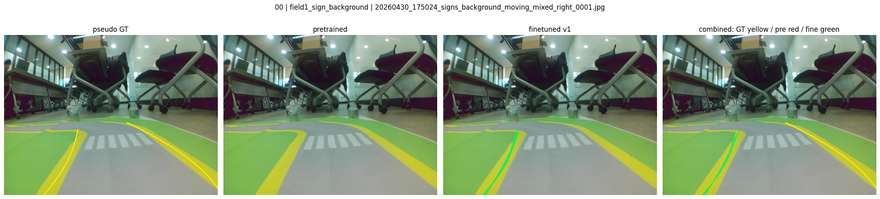

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\02_holdout_visual_compare_finetune_v1\overlays\01_field1_sign_background.png


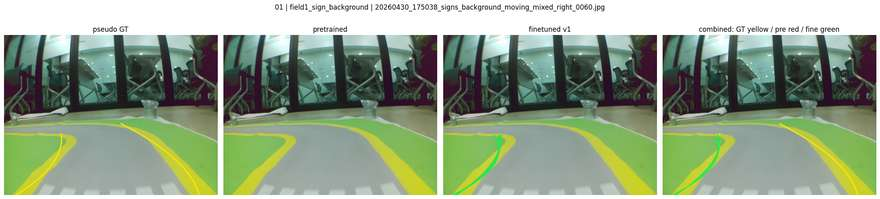

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\02_holdout_visual_compare_finetune_v1\overlays\02_field1_sign_background.png


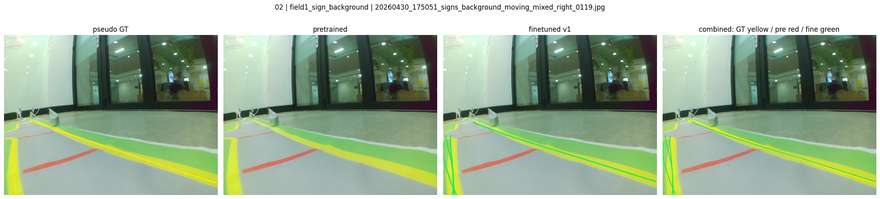

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\02_holdout_visual_compare_finetune_v1\overlays\03_field1_sign_background.png


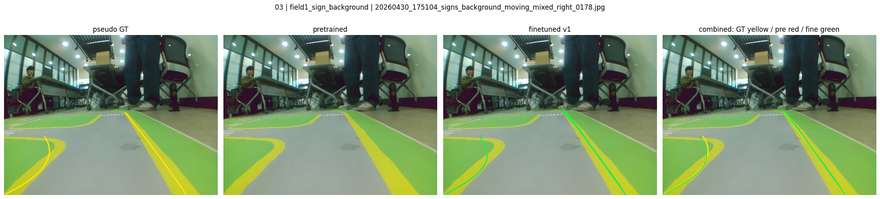

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\02_holdout_visual_compare_finetune_v1\overlays\04_field1_sign_background.png


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\02_holdout_visual_compare_finetune_v1\overlays\05_field1_sign_background.png


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\02_holdout_visual_compare_finetune_v1\overlays\06_field1_sign_background.png


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\02_holdout_visual_compare_finetune_v1\overlays\07_field1_sign_background.png


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\02_holdout_visual_compare_finetune_v1\overlays\08_field2_traffic_background.png


...

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\02_holdout_visual_compare_finetune_v1\overlays\11_field2_traffic_background.png


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\02_holdout_visual_compare_finetune_v1\overlays\12_field2_traffic_background.png


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\02_holdout_visual_compare_finetune_v1\overlays\13_field2_traffic_background.png


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\02_holdout_visual_compare_finetune_v1\overlays\14_field2_traffic_background.png


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\02_holdout_visual_compare_finetune_v1\overlays\15_field2_traffic_background.png


In [8]:
DISPLAY_LIMIT = len(cache['samples'])

for idx in range(min(DISPLAY_LIMIT, len(cache['samples']))):
    show_compare(idx, save=True)

## 9. 수동 판정 메모

아래 기준으로 직접 보면서 판단함.

좋은 신호:

- fine-tuned 초록 선이 노란 pseudo GT 근처에 꾸준히 나타남.
- pretrained 빨간 선이 아예 없거나 이상한 곳을 잡는데, fine-tuned는 도로 양쪽 노란 선을 잡음.
- 곡선/교차로/조명 차이에서도 fine-tuned 출력이 끊기지 않음.

위험 신호:

- fine-tuned가 실제 노란선이 아닌 엉뚱한 곳에 ghost lane을 많이 그림.
- pseudo GT 자체가 틀린 이미지가 많아서 모델이 나쁜 방향으로 학습된 것처럼 보임.
- fine-tuned가 한쪽 선만 너무 자주 잡아서 제어 로직에서 중앙 계산이 불안정해질 가능성이 큼.

판단 메모는 실행 후 아래에 직접 적으면 됨.

In [9]:
# 실행 후 직접 메모용.
# 예시:
# verdict = "finetuned가 pretrained보다 holdout에서 lane output을 훨씬 잘 살림. 다만 코너 일부에서 ghost lane 확인 필요."
verdict = ""
print(verdict if verdict else '아직 수동 판정 메모를 작성하지 않았음.')

아직 수동 판정 메모를 작성하지 않았음.


## 10. 현재 노트북의 결론을 어떻게 읽을 것인가

이 노트북의 결론은 다음 셋 중 하나로 내려야 함.

1. **통과**: fine-tuned v1이 holdout에서 pretrained보다 명확히 좋아짐. 다음 단계는 ONNX export와 Pi latency 측정임.
2. **부분 통과**: 출력은 살아났지만 ghost lane/한쪽 lane/교차로 실패가 큼. 다음 단계는 threshold, NMS, postprocess/control 로직을 함께 조정함.
3. **보류**: pseudo GT가 잘못되었거나 fine-tuned가 holdout에서 무너짐. 다음 단계는 데이터셋 빌더 정책 또는 학습 schedule을 다시 조정함.

현재 1차 실행 확인 결과:

- `list/test.txt` 기준 field2 holdout 8장에서는 pretrained가 전부 lane 0개였음.
- 같은 8장에서 fine-tuned v1은 7/8장에서 lane을 출력했음.
- 즉, **도메인 적응 효과는 분명히 보임.**
- 다만 fine-tuned 출력 개수가 pseudo GT보다 많은 장면이 있어 ghost lane / 중복 lane 가능성이 있음.
- 그리고 `list/test.txt`만 사용하면 field1 holdout이 빠지는 문제가 확인되어, 샘플 선정 기준을 `build_manifest.csv`의 usable 전체로 수정했음.

따라서 이 노트북은 다시 section 3부터 실행해 field1 + field2 holdout을 모두 확인한 뒤 최종 판정하는 것이 맞음.

중요한 점은, validation F1만 보고 끝내지 않는다는 것임. 우리 프로젝트는 실제 map 완주가 목표라서, **숫자 → holdout 이미지 → ONNX/Pi → 저속 주행** 순서로 판단해야 함.

## 11. 실행 결과 메모

이번 실행은 `build_manifest.csv`의 usable holdout 전체에서 scene별 8장씩, 총 16장을 뽑아 비교했음.

정량 요약:

- pretrained `ResNet18_CULane.pth`: 16/16장 모두 lane 0개
- fine-tuned v1 `best.pth`: 14/16장에서 lane 후보 출력
- fine-tuned 누락 케이스: `06_field1_sign_background`, `12_field2_traffic_background`
- fine-tuned 평균 출력 개수: field1 3.5개, field2 3.5개
- pseudo GT 평균 개수: field1 1.875개, field2 1.75개

시각 판단:

- fine-tuned v1은 pretrained와 달리 우리 map의 노란 차선 곡선을 실제로 잡기 시작했음.
- 일부 장면은 pseudo GT와 꽤 잘 겹침. 특히 곡선 양쪽 차선이 보이는 장면에서 도메인 적응 효과가 확실히 보임.
- 그러나 일부 장면에서는 한쪽 차선을 누락하거나, GT보다 많은 후보를 4개까지 출력함.
- 이 4개 출력은 반드시 모두 제어에 쓰면 안 됨. 다음 단계에서 후처리로 “주행에 필요한 좌/우 lane 또는 중심 계산에 쓸 lane”만 선택해야 함.

현재 판정:

- `finetune_v1`은 **도메인 적응 효과 확인** 단계는 통과로 봐도 됨.
- 하지만 “그대로 주행 제어에 연결 가능”은 아직 아님.
- 다음 단계는 fine-tuned checkpoint를 기준으로 lane 후보 선택/postprocess를 설계하고, 그 다음 ONNX export 및 Pi latency 검증으로 넘어가는 것이 맞음.